# Tutorial de una aplicacion web de ML con Flask

Este notebook documenta el desarrollo completo de una solucion de Machine Learning integrada en una aplicacion web con Flask. El flujo cubre la seleccion del dataset, la exploracion de datos, el entrenamiento del modelo, la optimizacion, la persistencia de artefactos y la validacion tecnica necesaria para desplegar el proyecto en Render.

**Objetivo del proyecto:** construir una aplicacion web capaz de recibir medidas de una flor Iris y predecir su especie usando un modelo entrenado previamente.


## Checklist de la consigna

| Requisito | Evidencia en este proyecto |
|---|---|
| Buscar y comprender un dataset nuevo | Se usa el UCI Iris Dataset, cargado desde `sklearn.datasets.load_iris`. |
| Modelar los datos con ML | Se entrena un pipeline `StandardScaler` + `RandomForestClassifier`. |
| Analizar y optimizar resultados | Se comparan modelo base y modelo optimizado con `GridSearchCV`. |
| Crear aplicacion Flask | La app principal esta en `app.py` con formulario web y ruta `/health`. |
| Preparar despliegue en Render | Se incluyen `Procfile`, `render.yaml`, `requirements.txt` y modelo serializado. |


In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from src.app import METRICS_PATH, MODEL_PATH, REPORTS_DIR, train_and_save_model
from src.utils import FEATURE_COLUMNS, TARGET_COLUMN, load_iris_dataframe, predict_species

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\frang\OneDrive\Escritorio\Tutorial-de-una-aplicaci-n-web-de-ML-con-Flask-Dragcessa1998


## 1. Dataset seleccionado

Para mantener el proyecto enfocado en la integracion ML + Flask, se selecciono el **UCI Iris Dataset**, un conjunto de datos pequeno, limpio y muy utilizado para problemas de clasificacion multiclase.

Cada registro representa una flor Iris descrita por cuatro medidas botanicas en centimetros. La variable objetivo es la especie: `setosa`, `versicolor` o `virginica`.


In [2]:
df = load_iris_dataframe()

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()


Filas: 150
Columnas: 5


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
data_dictionary = pd.DataFrame(
    [
        {"column": "sepal_length_cm", "description": "Longitud del sepalo en centimetros", "role": "feature"},
        {"column": "sepal_width_cm", "description": "Ancho del sepalo en centimetros", "role": "feature"},
        {"column": "petal_length_cm", "description": "Longitud del petalo en centimetros", "role": "feature"},
        {"column": "petal_width_cm", "description": "Ancho del petalo en centimetros", "role": "feature"},
        {"column": "species", "description": "Especie de Iris a predecir", "role": "target"},
    ]
)

data_dictionary


,column,description,role
0,sepal_length_cm,Longitud del sepalo en centimetros,feature
1,sepal_width_cm,Ancho del sepalo en centimetros,feature
2,petal_length_cm,Longitud del petalo en centimetros,feature
3,petal_width_cm,Ancho del petalo en centimetros,feature
4,species,Especie de Iris a predecir,target


## 2. Comprension y calidad de datos

Antes de modelar se revisan tipos de datos, valores nulos, cardinalidad y balance de clases. Esto permite confirmar si se necesitan imputaciones, conversiones o tratamientos adicionales.


In [4]:
quality_report = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "unique_values": df.nunique(),
    }
)

quality_report


,dtype,missing_values,missing_rate,unique_values
sepal_length_cm,float64,0,0.0,35
sepal_width_cm,float64,0,0.0,23
petal_length_cm,float64,0,0.0,43
petal_width_cm,float64,0,0.0,22
species,str,0,0.0,3


In [5]:
class_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .rename_axis("species")
    .reset_index(name="records")
)
class_distribution["percentage"] = (class_distribution["records"] / len(df) * 100).round(2)
class_distribution


,species,records,percentage
0,setosa,50,33.33
1,versicolor,50,33.33
2,virginica,50,33.33


In [6]:
df[FEATURE_COLUMNS].describe().T


,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,150.0,5.8433,0.8281,4.3,5.1,5.80,6.4,7.9
sepal_width_cm,150.0,3.0573,0.4359,2.0,2.8,3.00,3.3,4.4
petal_length_cm,150.0,3.7580,1.7653,1.0,1.6,4.35,5.1,6.9
petal_width_cm,150.0,1.1993,0.7622,0.1,0.3,1.30,1.8,2.5


In [7]:
df.groupby(TARGET_COLUMN)[FEATURE_COLUMNS].mean().round(3)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


## 3. Analisis visual

Las visualizaciones ayudan a entender la separacion entre clases. En este dataset, las variables del petalo suelen ser mas discriminantes que las variables del sepalo, lo que luego se confirma con la importancia de variables del modelo.


species_distribution.png


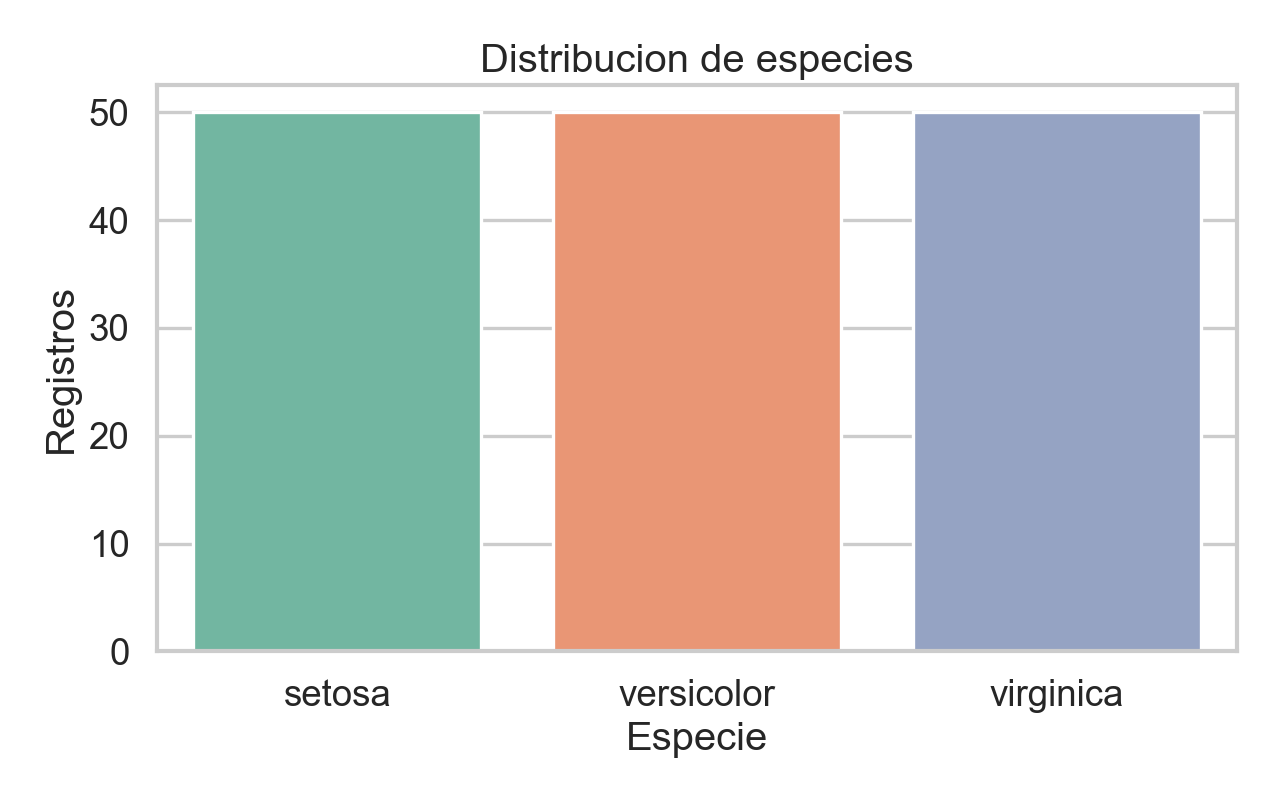

petal_scatter.png


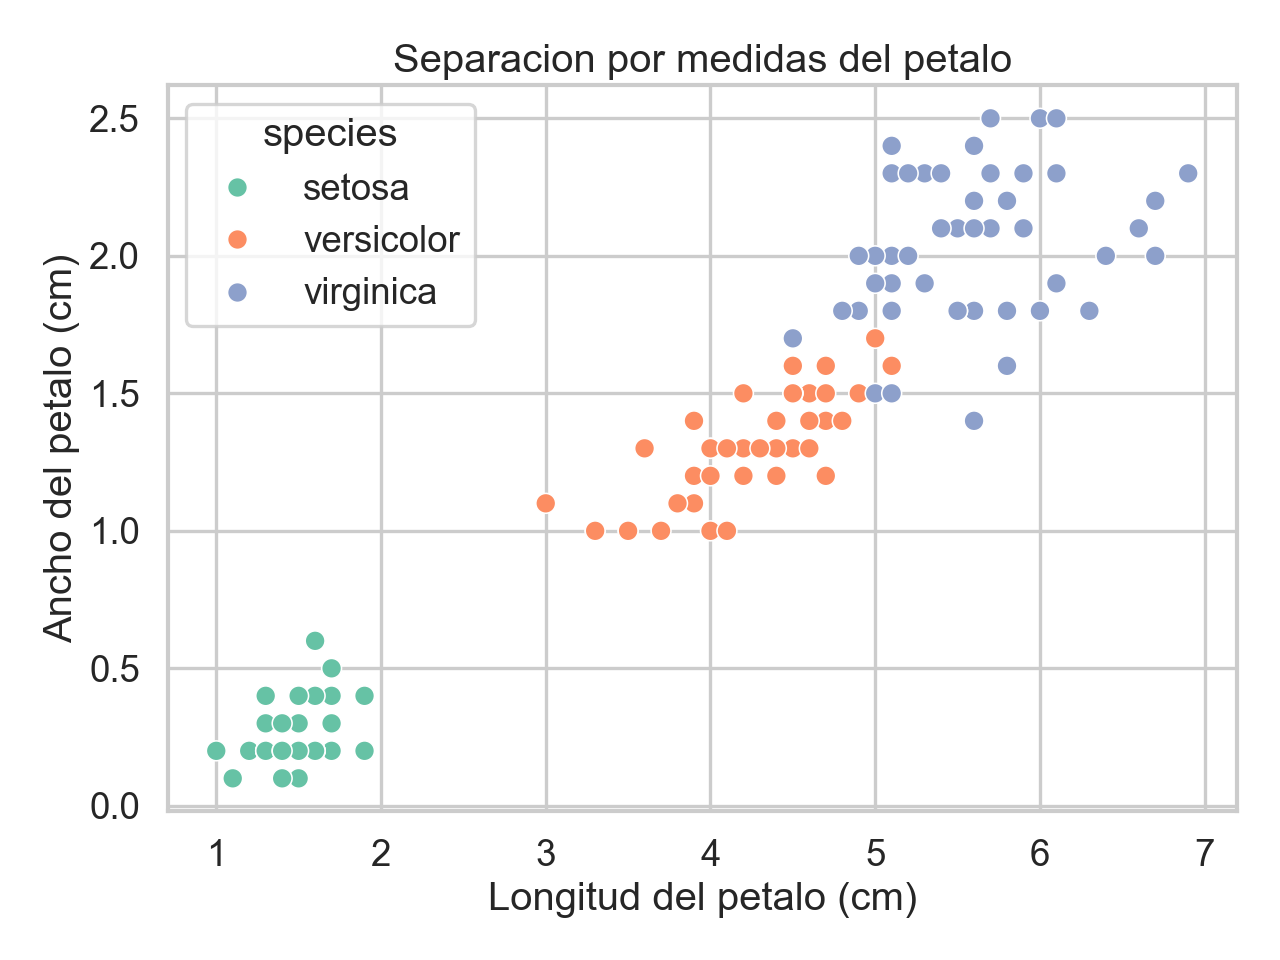

In [8]:
# Las figuras se generan tambien desde src/app.py para que queden guardadas como artefactos del repositorio.
train_and_save_model()

for figure in ["species_distribution.png", "petal_scatter.png"]:
    print(figure)
    display(Image(filename=str(REPORTS_DIR / figure)))


## 4. Preparacion para modelado

El proyecto usa las cuatro columnas numericas como variables predictoras y `species` como variable objetivo. La division train/test se realiza con estratificacion para conservar el balance de clases en ambos subconjuntos.

El pipeline aplica:

- `StandardScaler` para escalar variables numericas.
- `RandomForestClassifier` como modelo principal.
- `GridSearchCV` para buscar una configuracion mas competitiva.


In [9]:
results = train_and_save_model()

pd.DataFrame(
    [
        {"subset": "train", "records": results["dataset"]["train_rows"]},
        {"subset": "test", "records": results["dataset"]["test_rows"]},
    ]
)


,subset,records
0,train,120
1,test,30


In [10]:
pd.DataFrame(
    {
        "feature": results["dataset"]["features"],
        "used_by_model": True,
    }
)


,feature,used_by_model
0,sepal_length_cm,True
1,sepal_width_cm,True
2,petal_length_cm,True
3,petal_width_cm,True


## 5. Entrenamiento y optimizacion

Se entrenan dos versiones:

1. **Modelo base:** Random Forest con parametros por defecto del proyecto.
2. **Modelo optimizado:** Random Forest ajustado con `GridSearchCV`.

La comparacion se realiza con `accuracy` y `macro_f1`, utiles en clasificacion multiclase balanceada.


In [11]:
metric_columns = ["accuracy", "macro_f1"]
model_comparison = pd.DataFrame(
    [
        {"model": "baseline", **{metric: results["baseline_model"][metric] for metric in metric_columns}},
        {"model": "optimized", **{metric: results["optimized_model"][metric] for metric in metric_columns}},
    ]
)

model_comparison


,model,accuracy,macro_f1
0,baseline,0.9000,0.8997
1,optimized,0.9333,0.9333


In [12]:
print("Best hyperparameters:")
print(json.dumps(results["optimized_model"]["best_params"], indent=2))
print(f"Best CV accuracy: {results['optimized_model']['best_cv_accuracy']:.4f}")


Best hyperparameters:
{
  "classifier__max_depth": 2,
  "classifier__min_samples_leaf": 1,
  "classifier__n_estimators": 80
}
Best CV accuracy: 0.9583


In [13]:
confusion = pd.DataFrame(
    results["optimized_model"]["confusion_matrix"],
    index=[f"actual_{label}" for label in results["dataset"]["classes"]],
    columns=[f"pred_{label}" for label in results["dataset"]["classes"]],
)

confusion


,pred_setosa,pred_versicolor,pred_virginica
actual_setosa,10,0,0
actual_versicolor,0,9,1
actual_virginica,0,1,9


In [14]:
report = pd.DataFrame(results["optimized_model"]["classification_report"]).T
report.loc[results["dataset"]["classes"], ["precision", "recall", "f1-score", "support"]]


,precision,recall,f1-score,support
setosa,1.0,1.0,1.0,10.0
versicolor,0.9,0.9,0.9,10.0
virginica,0.9,0.9,0.9,10.0


## 6. Interpretacion del modelo

El modelo permite revisar la importancia relativa de cada variable. Esta informacion es util para explicar al usuario que medidas influyen mas en la prediccion.


In [15]:
importance = pd.DataFrame(results["feature_importance"])
importance


,feature,importance
0,petal_width_cm,0.4412
1,petal_length_cm,0.4271
2,sepal_length_cm,0.1309
3,sepal_width_cm,0.0008


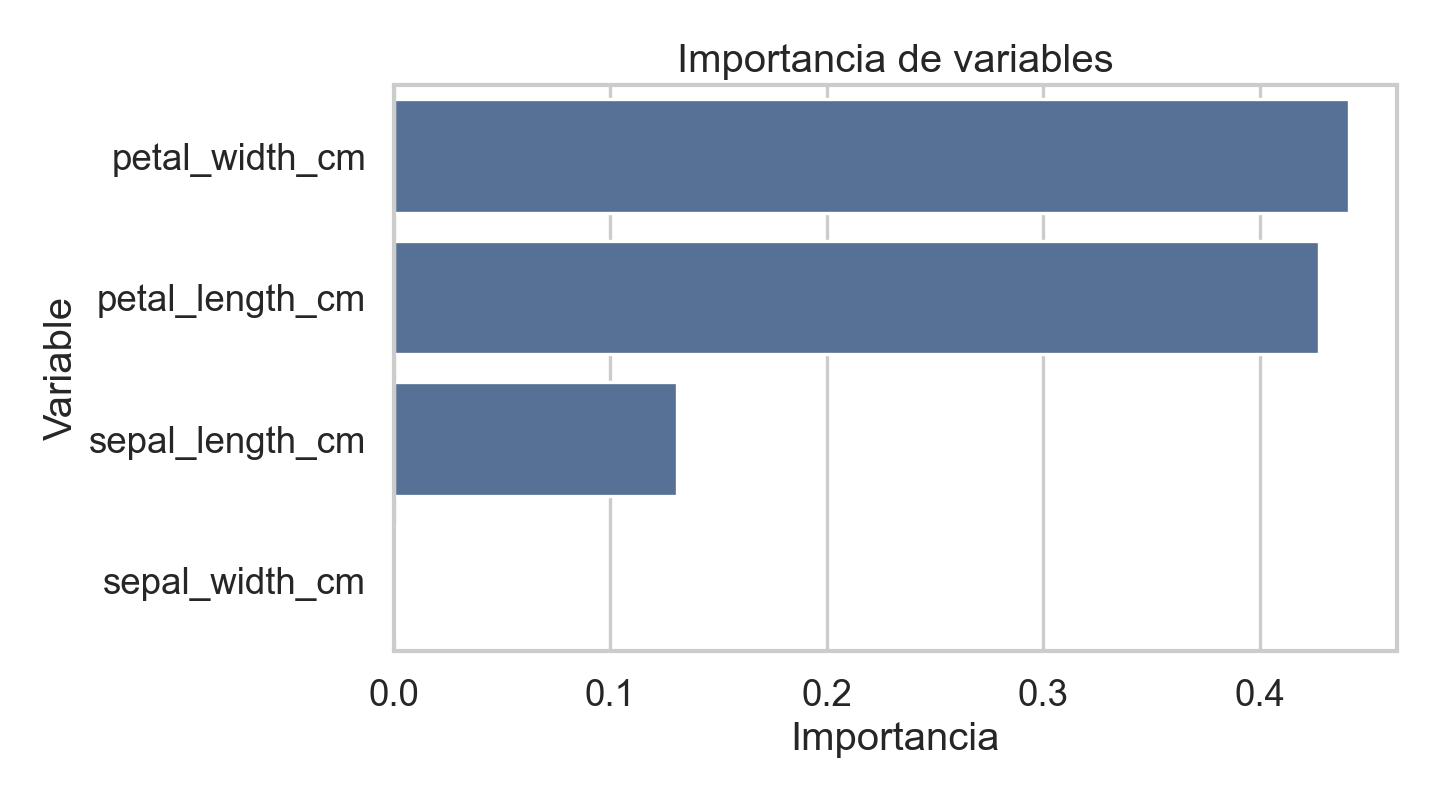

In [16]:
display(Image(filename=str(REPORTS_DIR / "feature_importance.png")))


## 7. Persistencia de artefactos

Para que Flask pueda usar el modelo sin reentrenar en cada solicitud, se guarda un artefacto `.joblib` con el pipeline entrenado, las columnas de entrada y las clases disponibles. Tambien se guardan metricas y datasets procesados para trazabilidad.


In [17]:
artifact_checks = []
for path in [
    PROJECT_ROOT / "data" / "raw" / "iris.csv",
    PROJECT_ROOT / "data" / "processed" / "train.csv",
    PROJECT_ROOT / "data" / "processed" / "test.csv",
    MODEL_PATH,
    METRICS_PATH,
    REPORTS_DIR / "species_distribution.png",
    REPORTS_DIR / "feature_importance.png",
    REPORTS_DIR / "petal_scatter.png",
]:
    artifact_checks.append(
        {
            "artifact": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else 0,
        }
    )

pd.DataFrame(artifact_checks)


,artifact,exists,size_kb
0,data\raw\iris.csv,True,3.93
1,data\processed\train.csv,True,3.16
2,data\processed\test.csv,True,0.84
3,models\iris_classifier.joblib,True,72.98
4,models\iris_metrics.json,True,3.44
5,reports\figures\species_distribution.png,True,38.62
6,reports\figures\feature_importance.png,True,46.14
7,reports\figures\petal_scatter.png,True,105.52


## 8. Prueba de inferencia

La siguiente prueba usa exactamente la funcion de prediccion que consume la aplicacion Flask. Esto valida que el artefacto guardado puede cargarse y producir una respuesta lista para mostrar en la interfaz.


In [18]:
artifact = joblib.load(MODEL_PATH)

sample = {
    "sepal_length_cm": 5.8,
    "sepal_width_cm": 3.0,
    "petal_length_cm": 4.3,
    "petal_width_cm": 1.3,
}

prediction = predict_species(artifact, sample)
prediction


{'prediction': 'versicolor',
 'probabilities': {np.str_('setosa'): 0.0099,
  np.str_('versicolor'): 0.9179,
  np.str_('virginica'): 0.0722}}

In [19]:
pd.DataFrame(
    prediction["probabilities"].items(),
    columns=["species", "probability"],
).sort_values("probability", ascending=False)


,species,probability
1,versicolor,0.9179
2,virginica,0.0722
0,setosa,0.0099


## 9. Validacion de la aplicacion Flask

La app web se valida con el cliente de pruebas de Flask. Se comprueba que:

- `/health` responda correctamente.
- El formulario acepte datos numericos.
- La pagina de prediccion devuelva una respuesta HTTP valida.


In [20]:
import importlib.util

flask_app_path = PROJECT_ROOT / "app.py"
spec = importlib.util.spec_from_file_location("flask_web_app", flask_app_path)
flask_web_app = importlib.util.module_from_spec(spec)
spec.loader.exec_module(flask_web_app)

with flask_web_app.app.test_client() as client:
    health_response = client.get("/health")
    debug_response = client.get("/debug-paths")
    prediction_response = client.post("/", data=sample)

prediction_rendered = prediction_response.status_code == 200 and b"Predicted species" in prediction_response.data
flask_validation = pd.DataFrame(
    [
        {
            "route": "/health",
            "status_code": health_response.status_code,
            "valid": health_response.status_code == 200 and health_response.json.get("status") == "ok",
            "details": health_response.json,
        },
        {
            "route": "/debug-paths",
            "status_code": debug_response.status_code,
            "valid": debug_response.status_code == 200 and debug_response.json.get("index_template_exists") is True,
            "details": {
                "template_folder": debug_response.json.get("template_folder"),
                "index_template_exists": debug_response.json.get("index_template_exists"),
            },
        },
        {
            "route": "/",
            "status_code": prediction_response.status_code,
            "valid": prediction_rendered,
            "details": "Prediction page rendered successfully" if prediction_rendered else prediction_response.data[:200].decode("utf-8", errors="replace"),
        },
    ]
)

assert flask_validation["valid"].all(), "Flask validation failed. Review the route diagnostics above."
flask_validation


,route,status_code,valid,details
0,/health,200,True,"{'model_available': True, 'status': 'ok'}"
1,/debug-paths,200,True,{'template_folder': 'C:\Users\frang\OneDrive\E...
2,/,200,True,Prediction page rendered successfully


## 10. Preparacion para Render

Render necesita saber como instalar dependencias y como iniciar la aplicacion. Este repositorio incluye los archivos necesarios:

- `requirements.txt`: dependencias del proyecto.
- `Procfile`: comando de arranque para Gunicorn.
- `render.yaml`: configuracion declarativa del servicio.
- `models/iris_classifier.joblib`: modelo listo para inferencia.

Cuando se cree el servicio gratuito en Render, el comando esperado es `gunicorn app:app`.


In [21]:
render_files = ["requirements.txt", "Procfile", "render.yaml", "app.py", "models/iris_classifier.joblib"]

pd.DataFrame(
    [
        {
            "file": file,
            "exists": (PROJECT_ROOT / file).exists(),
        }
        for file in render_files
    ]
)


,file,exists
0,requirements.txt,True
1,Procfile,True
2,render.yaml,True
3,app.py,True
4,models/iris_classifier.joblib,True


In [22]:
print("Procfile:")
print((PROJECT_ROOT / "Procfile").read_text(encoding="utf-8").strip())

print("\nrender.yaml:")
print((PROJECT_ROOT / "render.yaml").read_text(encoding="utf-8").strip())


Procfile:
web: gunicorn app:app

render.yaml:
services:
  - type: web
    name: iris-ml-flask-dragcessa1998
    env: python
    plan: free
    buildCommand: pip install -r requirements.txt
    startCommand: gunicorn app:app
    autoDeploy: true
